In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

In [9]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
nigeria["Country"] = "Nigeria"
sudan["Country"] = "sudan"
tanzania["Country"] = "tanzania"

In [10]:
df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania])

In [11]:
df["Country"].value_counts()

Country
Ethiopia    4108
Kenya       4108
Nigeria     4108
sudan       4108
tanzania    4108
Name: count, dtype: int64

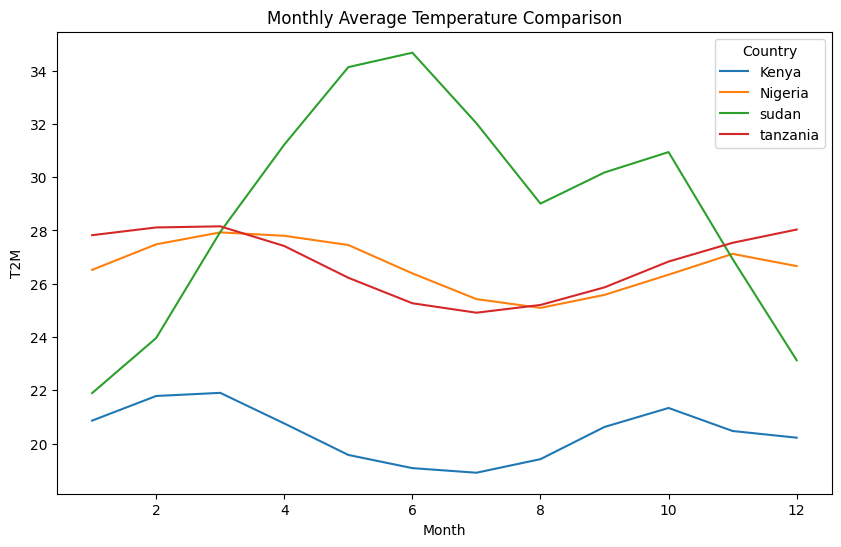

In [12]:
monthly_temp = df.groupby(["Month","Country"])["T2M"].mean().reset_index()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_temp, x="Month", y="T2M", hue="Country")
plt.title("Monthly Average Temperature Comparison")
plt.show()

In [13]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean","median","std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
sudan,28.759007,29.16,4.681305
tanzania,26.802422,26.99,1.325388


## Temperature Comparison

The temperature trends show noticeable differences across countries.

Countries with higher mean temperatures indicate hotter climates, while higher standard deviation suggests more variability.

These differences reflect geographic and climatic diversity across the region.

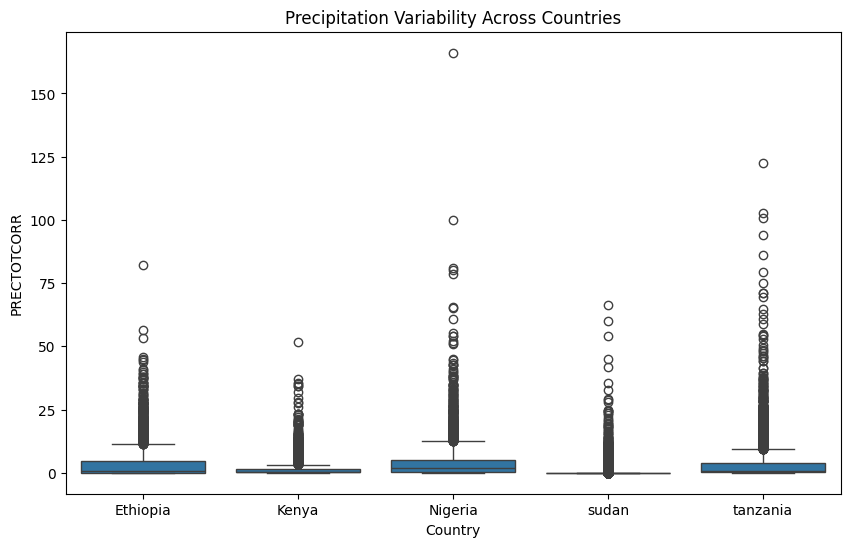

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Variability Across Countries")
plt.show()

In [15]:
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean","median","std"])
rain_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
sudan,0.643875,0.00,3.057672
tanzania,3.740256,0.64,8.003947


## Precipitation Comparison

Precipitation varies significantly across countries.

Countries with higher variability are more prone to extreme rainfall events and potential flooding, while lower values indicate drier climates.

This variability is a key factor in climate vulnerability.

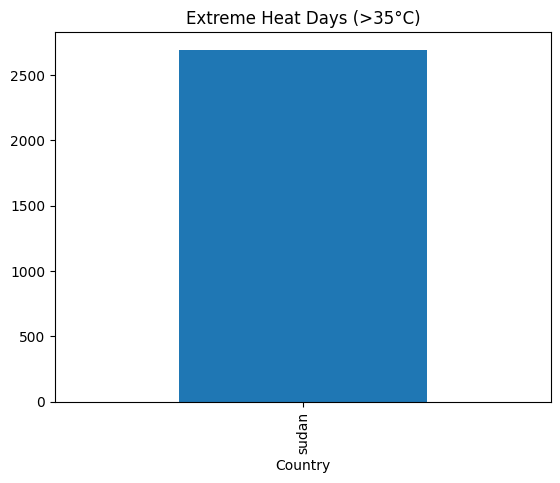

In [16]:
extreme_heat = df[df["T2M_MAX"] > 35]

heat_counts = extreme_heat.groupby("Country").size()

heat_counts.plot(kind="bar", title="Extreme Heat Days (>35°C)")
plt.show()

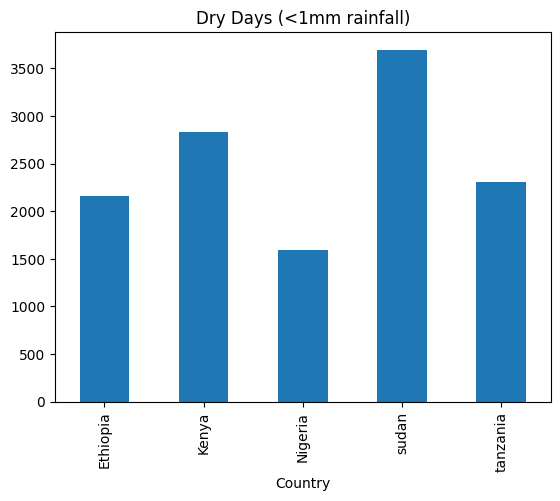

In [17]:
dry_days = df[df["PRECTOTCORR"] < 1]

dry_counts = dry_days.groupby("Country").size()

dry_counts.plot(kind="bar", title="Dry Days (<1mm rainfall)")
plt.show()

## Extreme Climate Events

Extreme heat days and prolonged dry periods are indicators of climate stress.

Countries with higher counts of extreme heat and dry days are more vulnerable to drought, agricultural loss, and water scarcity.

In [18]:
from scipy.stats import f_oneway

groups = [group["T2M"].dropna() for name, group in df.groupby("Country")]

f_stat, p_value = f_oneway(*groups)

print("p-value:", p_value)

p-value: 0.0


## Statistical Significance

The ANOVA test evaluates whether temperature differences between countries are statistically significant.

A p-value less than 0.05 indicates that the differences are significant and not due to random variation.

In [19]:
ranking = pd.DataFrame({
    "Temp_Variability": temp_summary["std"],
    "Rain_Variability": rain_summary["std"],
    "Extreme_Heat": heat_counts,
    "Dry_Days": dry_counts
}).fillna(0)

ranking = ranking.sort_values(by=["Extreme_Heat","Dry_Days"], ascending=False)

ranking

,Temp_Variability,Rain_Variability,Extreme_Heat,Dry_Days
Country,,,,
sudan,4.681305,3.057672,2694.0,3696
Kenya,1.440824,3.180228,0.0,2831
tanzania,1.325388,8.003947,0.0,2303
Ethiopia,1.898050,6.289061,0.0,2161
Nigeria,1.123335,7.266742,0.0,1595


## COP32 Climate Vulnerability Insights

- Countries with higher temperature variability and increasing trends are experiencing accelerated warming, indicating growing climate stress.
- Countries with high precipitation variability face increased risks of both flooding and drought, making their climate less predictable.
- High counts of extreme heat days and dry periods reveal significant exposure to climate extremes, which can impact agriculture and water resources.
- Ethiopia shows moderate climate variability but remains vulnerable due to its reliance on seasonal rainfall patterns.
- Based on the combined analysis, the most vulnerable country should be prioritized for climate finance due to its exposure to extreme heat, rainfall variability, and prolonged dry conditions.

In [ ]:
git add notebooks/
git commit -m "feat: cross-country comparison and vulnerability ranking"
git push

fatal: pathspec 'notebooks/' did not match any files


On branch eda-ethiopia
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   ../requirements.txt

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	../.cph/
	../A_Everybody_Likes_Good_Arrays.py
	./

no changes added to commit (use "git add" and/or "git commit -a")


fatal: The current branch eda-ethiopia has no upstream branch.
To push the current branch and set the remote as upstream, use

    git push --set-upstream origin eda-ethiopia

To have this happen automatically for branches without a tracking
upstream, see 'push.autoSetupRemote' in 'git help config'.

